In [1]:
import os
import json
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, RocCurveDisplay
)
from imblearn.over_sampling import SMOTE

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [2]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
# =======================================================
# PATH OUTPUT
# =======================================================
output_dir = "/content/drive/MyDrive/Tesis/Fix FE HO/ANN/Base Model/"
os.makedirs(output_dir, exist_ok=True)

# =======================================================
# LOAD DATASET
# =======================================================
file_path = '/content/drive/MyDrive/Tesis/Eksperimen/Dataset/Data Gabungan/fix_data_gabungan_fe_tambahan_2.csv'
df = pd.read_csv(file_path)
df.head()

,Hypothyroidism,Creatinine,Diabetes Mellitus (DM),Alanin Aminotransferaz (ALT),Low Density Lipoprotein (LDL),Hemoglobin (HGB),Coronary Artery Disease (CAD),Total Body Fat Ratio (TBFR) (%),Total Body Water (TBW),Height,...,Aspartat Aminotransferaz (AST),Glomerular Filtration Rate (GFR),Glucose,TC/HDL Ratio,LDL/HDL Ratio,Atherogenic Index,Triglyceride/HDL Ratio,Non-Lean Mass (NLM),Body Fat/Water Ratio,De Ritis Ratio
0,0,1.36,1,83.0,6.5,37.8,0,25.213043,36.87740,160.0,...,13.6,54.218927,130.0,6.243386,0.343915,5.243386,15.555556,-5.786957,0.683699,0.163855
1,0,0.81,0,16.0,75.0,14.3,0,13.352632,34.10012,170.0,...,25.0,94.586269,100.0,2.000000,1.000000,1.000000,0.866667,-29.647368,0.391571,1.562500
2,0,0.81,0,15.0,78.0,14.5,0,20.100000,34.67564,160.0,...,20.0,99.353543,100.0,2.083333,1.083333,1.083333,0.944444,-19.900000,0.579658,1.333333
3,0,0.81,0,14.0,78.0,15.1,0,21.885714,39.11164,170.0,...,23.0,99.353543,100.0,2.000000,1.040000,1.000000,0.866667,-8.114286,0.559570,1.642857
4,0,0.72,0,14.0,80.0,12.3,0,29.500000,26.26800,150.0,...,25.0,93.612393,98.0,2.384615,1.230769,1.384615,1.076923,-20.500000,1.123039,1.785714


In [4]:
target = "Gallstone Status"
X = df.drop(columns=[target])
y = df[target]

In [5]:
# Simpan urutan kolom agar Streamlit input sesuai
with open(output_dir + "columns.json", "w") as f:
    json.dump(list(X.columns), f, indent=4)

In [6]:
# =======================================================
# BUILD ANN MODEL
# =======================================================
def build_ann(input_dim):
    model = Sequential()
    model.add(Dense(64, activation='relu', input_dim=input_dim))
    model.add(Dropout(0.3))
    model.add(Dense(32, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

In [7]:
# =======================================================
# HOLD-OUT 80:20
# =======================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =======================================================
# SCALING
# =======================================================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Simpan scaler
joblib.dump(scaler, output_dir + "scaler.pkl")


['/content/drive/MyDrive/Tesis/Fix FE HO/ANN/Base Model/scaler.pkl']

In [8]:
# =======================================================
# SMOTE
# =======================================================
smote = SMOTE()
X_train, y_train = smote.fit_resample(X_train, y_train)

# =======================================================
# TRAIN ANN
# =======================================================
model = build_ann(X_train.shape[1])

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# Simpan model ANN
model.save(output_dir + "ann_model.h5")

# Simpan history training
with open(output_dir + "history.json", "w") as f:
    json.dump(history.history, f, indent=4)


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.4797 - loss: 0.7114 - val_accuracy: 0.6069 - val_loss: 0.6827
Epoch 2/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6914 - loss: 0.5886 - val_accuracy: 0.6276 - val_loss: 0.6341
Epoch 3/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7632 - loss: 0.5133 - val_accuracy: 0.6690 - val_loss: 0.5793
Epoch 4/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7875 - loss: 0.4721 - val_accuracy: 0.6828 - val_loss: 0.5875
Epoch 5/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7330 - loss: 0.4636 - val_accuracy: 0.6759 - val_loss: 0.5604
Epoch 6/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7601 - loss: 0.4525 - val_accuracy: 0.7172 - val_loss: 0.5310
Epoch 7/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7832 - loss: 0.4059 - val_accuracy: 0.7724 - val_loss: 0.4915
Epoch 8/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7930 - loss: 0.4233 - val_accuracy: 0.7931 - val_loss: 0.4799
Ep

In [9]:
# =======================================================
# PREDIKSI
# =======================================================
y_pred_prob = model.predict(X_test).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


In [10]:
# =======================================================
# EVALUASI
# =======================================================
print("\n===== HASIL HOLD-OUT 80:20 =====")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall   :", recall_score(y_test, y_pred, zero_division=0))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_pred_prob))


===== HASIL HOLD-OUT 80:20 =====
Accuracy : 0.7317073170731707
Precision: 0.48717948717948717
Recall   : 0.59375
F1 Score : 0.5352112676056338
ROC-AUC  : 0.8203983516483516


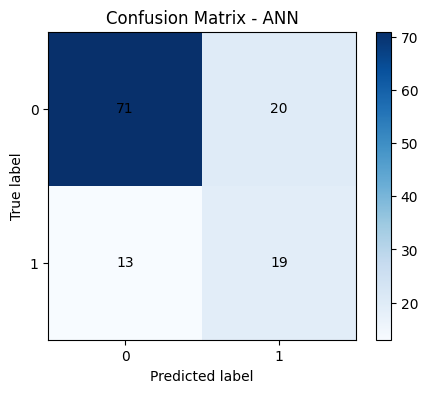

In [11]:
# =======================================================
# CONFUSION MATRIX
# =======================================================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
plt.imshow(cm, cmap='Blues')
plt.title("Confusion Matrix - ANN")
plt.colorbar()
plt.xticks([0,1], ["0","1"])
plt.yticks([0,1], ["0","1"])
plt.xlabel("Predicted label")
plt.ylabel("True label")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i,j], ha='center', va='center', color='black')

plt.savefig(output_dir + "confusion_matrix.png")
plt.show()

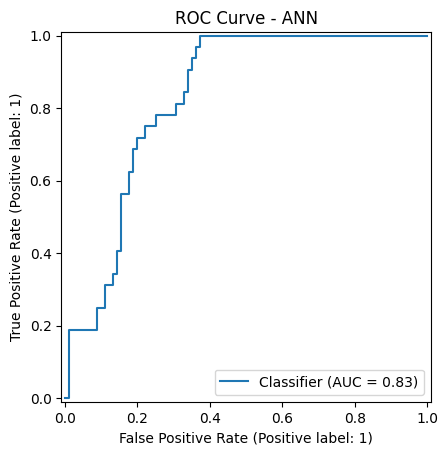

In [26]:
# =======================================================
# ROC CURVE
# =======================================================
RocCurveDisplay.from_predictions(y_test, y_pred_prob)
plt.title("ROC Curve - ANN")
plt.savefig(output_dir + "roc_curve.png")
plt.show()


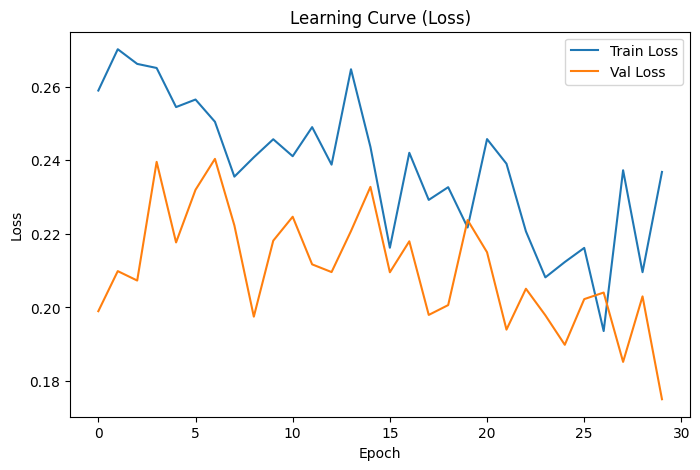

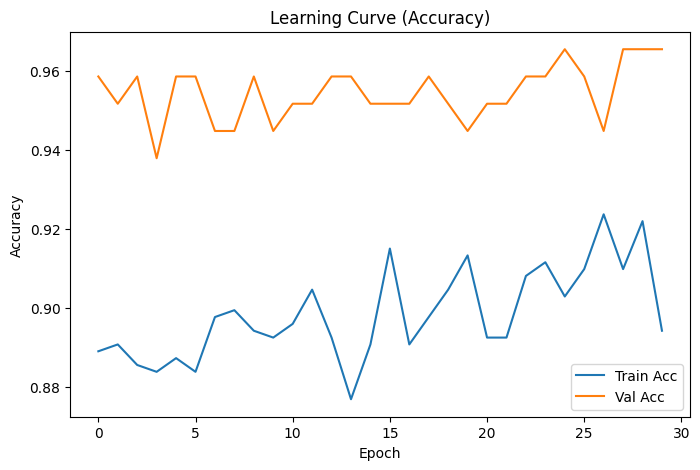

In [27]:
# =======================================================
# LEARNING CURVE
# =======================================================
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Learning Curve (Loss)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.savefig(output_dir + "learning_curve_loss.png")
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title("Learning Curve (Accuracy)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.savefig(output_dir + "learning_curve_acc.png")
plt.show()

hyperparameter tuning

In [28]:
import numpy as np
import json
import os

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

In [29]:
# ============================================================
# PASTIKAN PATH PENYIMPANAN
# ============================================================
SAVE_DIR = "/content/drive/MyDrive/Tesis/Fix FE HO/ANN/Tuned Model/"
os.makedirs(SAVE_DIR, exist_ok=True)

In [30]:
# ============================================================
# NORMALISASI
# ============================================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [31]:
# ============================================================
# FUNGSI BIKIN MODEL
# ============================================================
def build_model(learning_rate, dropout_rate, neurons):
    model = Sequential()
    model.add(Dense(neurons, activation='relu', input_shape=(X_train.shape[1],)))
    model.add(Dropout(dropout_rate))
    model.add(Dense(neurons, activation='relu'))
    model.add(Dropout(dropout_rate))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

In [32]:
# ============================================================
# PARAMETER SEARCH SPACE
# ============================================================
param_dist = {
    "learning_rate": [0.0001, 0.001, 0.01],
    "dropout_rate": [0.1, 0.2, 0.3, 0.4],
    "neurons": [16, 32, 64, 128],
    "batch_size": [16, 32, 64],
    "epochs": [20, 30, 50]
}

In [33]:
import random

# ============================================================
# RANDOM SEARCH MANUAL
# ============================================================
N_ITER = 10
best_score = -1
best_params = None
best_model = None

print("===== Mulai Random Search (Manual, Aman tanpa wrapper) =====")

===== Mulai Random Search (Manual, Aman tanpa wrapper) =====


In [34]:
for i in range(N_ITER):
    print(f"\nIterasi ke-{i+1}/{N_ITER}")

    # Random pilih parameter
    lr = random.choice(param_dist["learning_rate"])
    dr = random.choice(param_dist["dropout_rate"])
    ne = random.choice(param_dist["neurons"])
    bs = random.choice(param_dist["batch_size"])
    ep = random.choice(param_dist["epochs"])

    print(f"Params: lr={lr}, dropout={dr}, neurons={ne}, batch={bs}, epochs={ep}")

    model = build_model(lr, dr, ne)
    model.fit(X_train_scaled, y_train, batch_size=bs, epochs=ep, verbose=0)

    pred = (model.predict(X_test_scaled) > 0.5).astype(int)
    score = accuracy_score(y_test, pred)

    print(f"Accuracy: {score:.4f}")

    if score > best_score:
        best_score = score
        best_params = {
            "learning_rate": lr,
            "dropout_rate": dr,
            "neurons": ne,
            "batch_size": bs,
            "epochs": ep
        }
        best_model = model

# ============================================================
# SIMPAN PARAMETER TERBAIK
# ============================================================
print("\n===== BEST PARAMS =====")
print(best_params)

with open(os.path.join(SAVE_DIR, "best_params.json"), "w") as f:
    json.dump(best_params, f, indent=4)

# ============================================================
# SIMPAN MODEL KERAS
# ============================================================
best_model.save(os.path.join(SAVE_DIR, "best_ann_model.h5"))
print("Model disimpan!")

# SIMPAN SCALER
import joblib
joblib.dump(scaler, os.path.join(SAVE_DIR, "scaler.pkl"))
print("Scaler disimpan!")


Iterasi ke-1/10
Params: lr=0.01, dropout=0.3, neurons=64, batch=32, epochs=20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Accuracy: 0.7073

Iterasi ke-2/10
Params: lr=0.001, dropout=0.3, neurons=64, batch=64, epochs=50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Accuracy: 0.7805

Iterasi ke-3/10
Params: lr=0.001, dropout=0.1, neurons=32, batch=32, epochs=20


...

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Accuracy: 0.7398

Iterasi ke-10/10
Params: lr=0.0001, dropout=0.3, neurons=64, batch=32, epochs=20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


Accuracy: 0.7317

===== BEST PARAMS =====
{'learning_rate': 0.001, 'dropout_rate': 0.3, 'neurons': 64, 'batch_size': 64, 'epochs': 50}
Model disimpan!
Scaler disimpan!


In [35]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay
)
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# 1. PREDIKSI MENGGUNAKAN BEST MODEL
# ============================================================
y_pred_prob = best_model.predict(X_test_scaled).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)














4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


In [36]:
# ============================================================
# 2. HITUNG METRIK
# ============================================================
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_prob)

print("\n===== EVALUASI MODEL TERBAIK =====")
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {auc:.4f}")

print("\n===== Classification Report =====")
print(classification_report(y_test, y_pred))


===== EVALUASI MODEL TERBAIK =====
Accuracy  : 0.7805
Precision : 0.5581
Recall    : 0.7500
F1 Score  : 0.6400
ROC-AUC   : 0.8293

===== Classification Report =====
              precision    recall  f1-score   support

           0       0.90      0.79      0.84        91
           1       0.56      0.75      0.64        32

    accuracy                           0.78       123
   macro avg       0.73      0.77      0.74       123
weighted avg       0.81      0.78      0.79       123



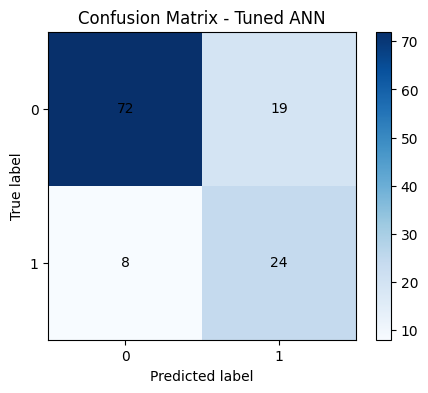

In [37]:
# ============================================================
# 3. CONFUSION MATRIX PLOT
# ============================================================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix - Tuned ANN")
plt.colorbar()
plt.xticks([0, 1], ["0", "1"])
plt.yticks([0, 1], ["0", "1"])
plt.xlabel("Predicted label")
plt.ylabel("True label")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center', color='black')

plt.show()

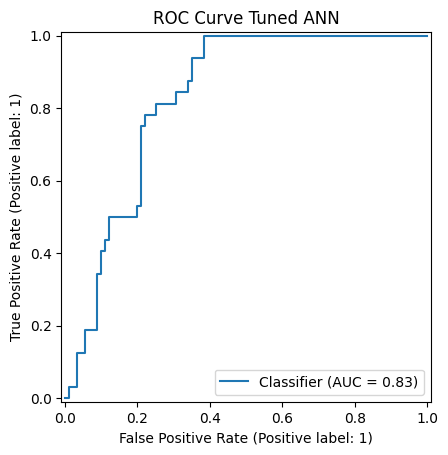

In [38]:
# ============================================================
# 4. ROC CURVE
# ============================================================
RocCurveDisplay.from_predictions(y_test, y_pred_prob)
plt.title("ROC Curve Tuned ANN")
plt.show()

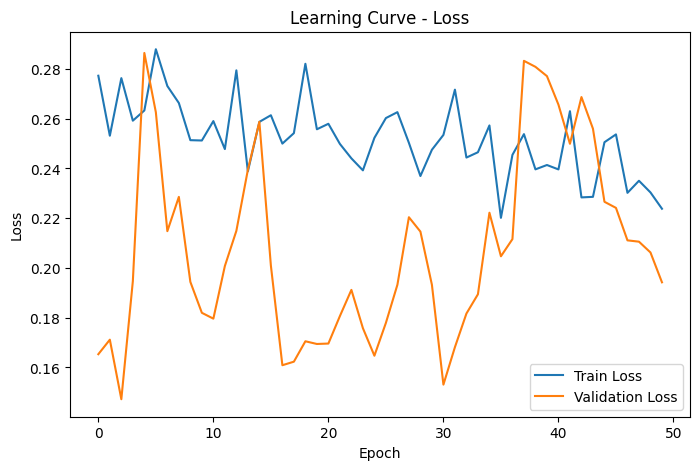

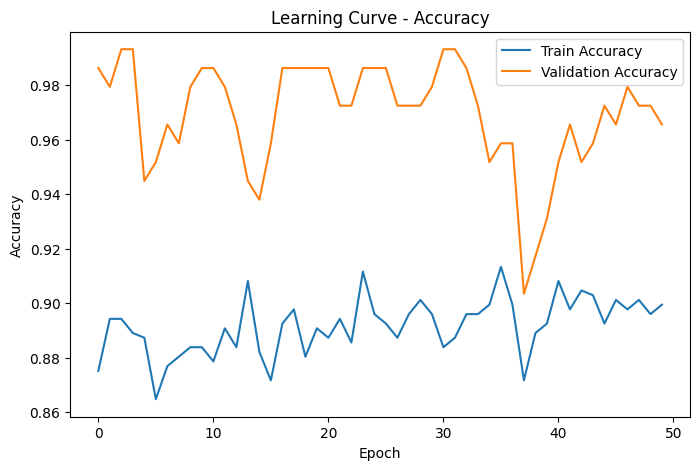

In [39]:
# ============================================================
# 5. LEARNING CURVE (LOSS & ACCURACY)
# ============================================================
# TRAIN BEST MODEL ULANG UNTUK MENDAPATKAN HISTORY
history = best_model.fit(
    X_train_scaled, y_train,
    epochs=best_params["epochs"],
    batch_size=best_params["batch_size"],
    validation_split=0.2,
    verbose=0
)

# ---------- PLOT LOSS ----------
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Learning Curve - Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# ---------- PLOT ACCURACY ----------
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Learning Curve - Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()











